# Product Data Exploration

This notebook explores the initial product dataset used in the Smart Warehouse Digital Twin project.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
products = pd.read_csv("../data/products.csv")
products

,product_id,product_name,category,unit_price,weight_kg
0,P001,Laptop,Electronics,850,1.8
1,P002,Wireless Mouse,Electronics,25,0.1
2,P003,Mechanical Keyboard,Electronics,70,0.8
3,P004,Office Chair,Furniture,180,12.5
4,P005,Desk Lamp,Home,35,1.2
5,P006,Monitor 27 inch,Electronics,300,5.5
6,P007,Standing Desk,Furniture,450,28.0
7,P008,USB-C Hub,Electronics,45,0.2
8,P009,Storage Box,Home,20,2.0
9,P010,Headphones,Electronics,90,0.3


## 1. Dataset Overview

Inspect the dataset structure, data types, missing values, and basic statistics.

In [4]:
products.head()

,product_id,product_name,category,unit_price,weight_kg
0,P001,Laptop,Electronics,850,1.8
1,P002,Wireless Mouse,Electronics,25,0.1
2,P003,Mechanical Keyboard,Electronics,70,0.8
3,P004,Office Chair,Furniture,180,12.5
4,P005,Desk Lamp,Home,35,1.2


In [5]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    10 non-null     object 
 1   product_name  10 non-null     object 
 2   category      10 non-null     object 
 3   unit_price    10 non-null     int64  
 4   weight_kg     10 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 528.0+ bytes


In [6]:
products.describe()

,unit_price,weight_kg
count,10.000000,10.000000
mean,206.500000,5.240000
std,266.302355,8.853022
min,20.000000,0.100000
25%,37.500000,0.425000
50%,80.000000,1.500000
75%,270.000000,4.625000
max,850.000000,28.000000


## 2. Product Statistics

Analyze product prices and weights and identify key characteristics.

In [7]:
products["weight_kg"].mean()

np.float64(5.24)

In [8]:
products.loc[products["weight_kg"].idxmin()]

product_id                P002
product_name    Wireless Mouse
category           Electronics
unit_price                  25
weight_kg                  0.1
Name: 1, dtype: object

## 3. Data Visualization

Visualize product prices, weights, and category distribution.

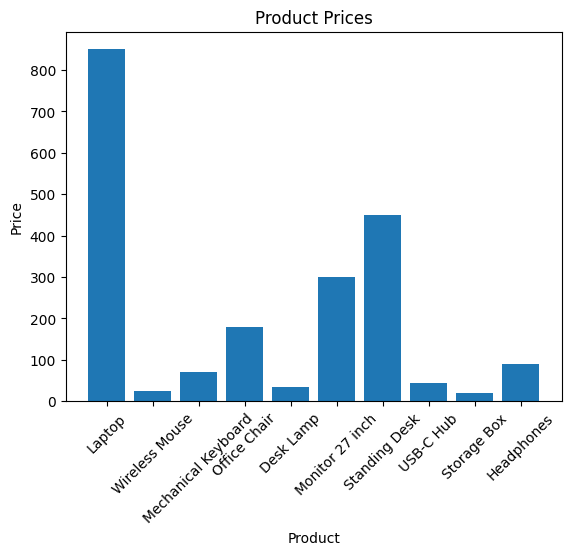

In [9]:
plt.bar(products["product_name"], products["unit_price"])
plt.xticks(rotation=45)
plt.xlabel("Product")
plt.ylabel("Price")
plt.title("Product Prices")
plt.show()

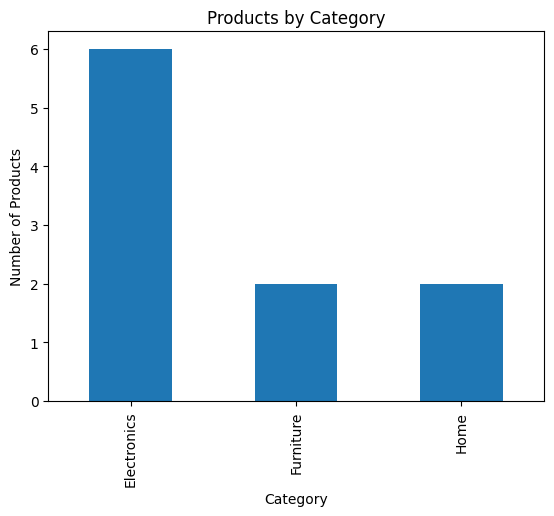

In [10]:
category_counts = products["category"].value_counts()
category_counts.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.title("Products by Category")
plt.show()

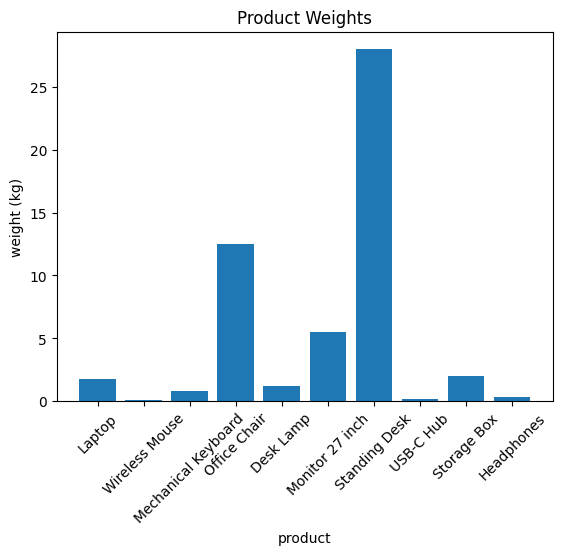

In [11]:
plt.bar(products["product_name"], products["weight_kg"])
plt.xticks(rotation=45)
plt.xlabel("product")
plt.ylabel("weight (kg)")
plt.title("Product Weights")
plt.show()

## 4. Category Analysis

Compare average price and weight across product categories.

In [12]:
products.groupby("category")["unit_price"].mean()

category
Electronics    230.0
Furniture      315.0
Home            27.5
Name: unit_price, dtype: float64

In [13]:
products.groupby("category")["weight_kg"].mean()

category
Electronics     1.45
Furniture      20.25
Home            1.60
Name: weight_kg, dtype: float64

In [14]:
products["category"].value_counts()

category
Electronics    6
Furniture      2
Home           2
Name: count, dtype: int64

## Key Findings

- Electronics is the largest category with 6 products.
- Furniture has the highest average product price.
- Furniture products are considerably heavier on average.
- The Wireless Mouse is the lightest product in the dataset.

# Order Data Exploration

Explore warehouse orders and prepare temporal data for demand analysis.

## 1. Order Dataset Overview

Load and inspect the order dataset to understand its structure and available features.

In [15]:
orders = pd.read_csv("../data/orders.csv")
orders.head()

,order_id,timestamp,product_id,quantity
0,O001,2026-01-01 09:15:00,P001,2
1,O002,2026-01-01 09:42:00,P003,1
2,O003,2026-01-01 10:10:00,P002,3
3,O004,2026-01-01 11:05:00,P001,1
4,O005,2026-01-01 12:20:00,P005,2


## 2. Temporal Data Preparation

Convert order timestamps to datetime format and explore temporal information such as dates, hours, and days of the week.

In [16]:
orders["timestamp"] = pd.to_datetime(orders["timestamp"])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    10 non-null     object        
 1   timestamp   10 non-null     datetime64[ns]
 2   product_id  10 non-null     object        
 3   quantity    10 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 448.0+ bytes


In [17]:
orders["timestamp"].dt.date

0    2026-01-01
1    2026-01-01
2    2026-01-01
3    2026-01-01
4    2026-01-01
5    2026-01-01
6    2026-01-01
7    2026-01-01
8    2026-01-02
9    2026-01-02
Name: timestamp, dtype: object

In [18]:
orders["timestamp"].dt.hour

0     9
1     9
2    10
3    11
4    12
5    14
6    15
7    17
8     8
9     9
Name: timestamp, dtype: int32

In [19]:
orders["timestamp"].dt.day_name()

0    Thursday
1    Thursday
2    Thursday
3    Thursday
4    Thursday
5    Thursday
6    Thursday
7    Thursday
8      Friday
9      Friday
Name: timestamp, dtype: object

## 3. Demand by Product

Aggregate ordered quantities by product to measure total demand for each product.

In [20]:
orders.groupby("product_id")["quantity"].sum()

product_id
P001    4
P002    7
P003    3
P005    2
P006    1
P010    2
Name: quantity, dtype: int64

## 4. Orders and Products Integration

Merge orders with product information using `product_id` to enrich order data with product details.

In [21]:
orders_with_products = orders.merge(
    products,
    on="product_id"
)

orders_with_products.head()

,order_id,timestamp,product_id,quantity,product_name,category,unit_price,weight_kg
0,O001,2026-01-01 09:15:00,P001,2,Laptop,Electronics,850,1.8
1,O002,2026-01-01 09:42:00,P003,1,Mechanical Keyboard,Electronics,70,0.8
2,O003,2026-01-01 10:10:00,P002,3,Wireless Mouse,Electronics,25,0.1
3,O004,2026-01-01 11:05:00,P001,1,Laptop,Electronics,850,1.8
4,O005,2026-01-01 12:20:00,P005,2,Desk Lamp,Home,35,1.2


In [22]:
orders_with_products.groupby("product_name")["quantity"].sum()

product_name
Desk Lamp              2
Headphones             2
Laptop                 4
Mechanical Keyboard    3
Monitor 27 inch        1
Wireless Mouse         7
Name: quantity, dtype: int64

## 5. Daily Demand Analysis

Aggregate order quantities by date to analyze how warehouse demand changes over time.

In [23]:
orders["date"] = orders["timestamp"].dt.date

In [24]:
orders.head()

,order_id,timestamp,product_id,quantity,date
0,O001,2026-01-01 09:15:00,P001,2,2026-01-01
1,O002,2026-01-01 09:42:00,P003,1,2026-01-01
2,O003,2026-01-01 10:10:00,P002,3,2026-01-01
3,O004,2026-01-01 11:05:00,P001,1,2026-01-01
4,O005,2026-01-01 12:20:00,P005,2,2026-01-01


In [25]:
orders.groupby("date")["quantity"].sum()

date
2026-01-01    16
2026-01-02     3
Name: quantity, dtype: int64

## 5. Daily Demand Analysis

### Daily Demand Visualization

Aggregate total order quantities by date and visualize daily warehouse demand as a time series.

In [26]:
daily_demand = orders.groupby("date")["quantity"].sum()

daily_demand

date
2026-01-01    16
2026-01-02     3
Name: quantity, dtype: int64

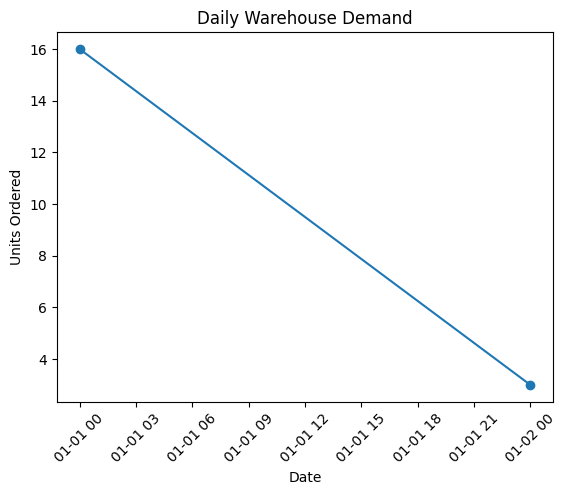

In [27]:
daily_demand.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Units Ordered")
plt.title("Daily Warehouse Demand")
plt.xticks(rotation=45)
plt.show()

## 6. Hourly Demand Analysis

Analyze total order quantities by hour of the day to identify intraday demand patterns in warehouse operations.

In [28]:
orders["hour"] = orders["timestamp"].dt.hour

orders[["timestamp", "hour"]].head()

,timestamp,hour
0,2026-01-01 09:15:00,9
1,2026-01-01 09:42:00,9
2,2026-01-01 10:10:00,10
3,2026-01-01 11:05:00,11
4,2026-01-01 12:20:00,12


In [29]:
hourly_demand = orders.groupby("hour")['quantity'].sum()
hourly_demand

hour
8     2
9     4
10    3
11    1
12    2
14    1
15    4
17    2
Name: quantity, dtype: int64

### Hourly Demand Visualization

Visualize total demand by hour of the day to identify periods of higher warehouse activity.

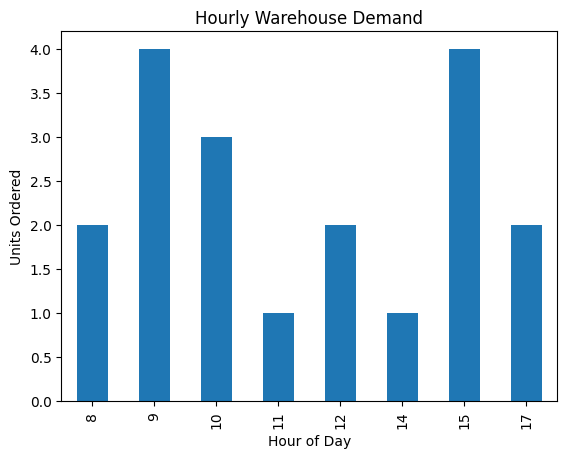

In [30]:
hourly_demand.plot(
    kind="bar"
)

plt.xlabel("Hour of Day")
plt.ylabel("Units Ordered")
plt.title("Hourly Warehouse Demand")
plt.show()

# Inventory Data Exploration

Explore current warehouse inventory levels and prepare stock data for inventory risk and replenishment analysis.

## 1. Inventory Dataset Overview

Load and inspect the inventory dataset to understand current stock levels and replenishment thresholds for each product.


In [31]:
inventory = pd.read_csv("../data/inventory.csv")

inventory.head()

,product_id,current_stock,reorder_point,max_stock
0,P001,12,5,30
1,P002,8,10,40
2,P003,15,8,35
3,P004,4,5,20
4,P005,20,6,30


In [32]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     10 non-null     object
 1   current_stock  10 non-null     int64 
 2   reorder_point  10 non-null     int64 
 3   max_stock      10 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 448.0+ bytes


## 2. Inventory Replenishment Analysis

Compare current stock levels with reorder points to identify products that may require replenishment.

In [33]:
inventory["current_stock"] <= inventory["reorder_point"]

0    False
1     True
2    False
3     True
4    False
5     True
6    False
7    False
8    False
9     True
dtype: bool

In [34]:
inventory["needs_reorder"] = (
    inventory["current_stock"] <= inventory["reorder_point"]
)

inventory

,product_id,current_stock,reorder_point,max_stock,needs_reorder
0,P001,12,5,30,False
1,P002,8,10,40,True
2,P003,15,8,35,False
3,P004,4,5,20,True
4,P005,20,6,30,False
5,P006,3,5,15,True
6,P007,7,4,12,False
7,P008,25,8,40,False
8,P009,18,5,25,False
9,P010,6,8,30,True


### Products Requiring Replenishment

Filter inventory records to identify products whose current stock is at or below the defined reorder point.

In [35]:
reorder_products = inventory[
    inventory["needs_reorder"]
]

reorder_products

,product_id,current_stock,reorder_point,max_stock,needs_reorder
1,P002,8,10,40,True
3,P004,4,5,20,True
5,P006,3,5,15,True
9,P010,6,8,30,True


In [36]:
inventory_with_products = inventory.merge(
    products,
    on = "product_id"
)
inventory_with_products

,product_id,current_stock,reorder_point,max_stock,needs_reorder,product_name,category,unit_price,weight_kg
0,P001,12,5,30,False,Laptop,Electronics,850,1.8
1,P002,8,10,40,True,Wireless Mouse,Electronics,25,0.1
2,P003,15,8,35,False,Mechanical Keyboard,Electronics,70,0.8
3,P004,4,5,20,True,Office Chair,Furniture,180,12.5
4,P005,20,6,30,False,Desk Lamp,Home,35,1.2
5,P006,3,5,15,True,Monitor 27 inch,Electronics,300,5.5
6,P007,7,4,12,False,Standing Desk,Furniture,450,28.0
7,P008,25,8,40,False,USB-C Hub,Electronics,45,0.2
8,P009,18,5,25,False,Storage Box,Home,20,2.0
9,P010,6,8,30,True,Headphones,Electronics,90,0.3


### Replenishment Candidates with Product Details

Combine inventory and product information to identify which specific products currently require replenishment.

In [37]:
replenishment_candidates = inventory_with_products[
    inventory_with_products["needs_reorder"]
]

replenishment_candidates[
    ["product_id", "product_name", "current_stock", "reorder_point", "max_stock"]
]

,product_id,product_name,current_stock,reorder_point,max_stock
1,P002,Wireless Mouse,8,10,40
3,P004,Office Chair,4,5,20
5,P006,Monitor 27 inch,3,5,15
9,P010,Headphones,6,8,30


In [38]:
inventory_with_products["reorder_quantity"] = inventory_with_products['max_stock']-inventory_with_products['current_stock']

### Replenishment Quantity

Calculate the quantity required to restore each product requiring replenishment to its maximum stock level.

In [39]:
replenishment_plan = inventory_with_products[
    inventory_with_products["needs_reorder"]
][
    [
        "product_id",
        "product_name",
        "current_stock",
        "reorder_point",
        "max_stock",
        "reorder_quantity"
    ]
]

replenishment_plan

,product_id,product_name,current_stock,reorder_point,max_stock,reorder_quantity
1,P002,Wireless Mouse,8,10,40,32
3,P004,Office Chair,4,5,20,16
5,P006,Monitor 27 inch,3,5,15,12
9,P010,Headphones,6,8,30,24


## 3. Inventory and Demand Integration

Combine inventory levels with observed product demand to evaluate stock availability relative to demand.

In [40]:
product_demand = (
    orders.groupby("product_id")["quantity"]
    .sum()
    .reset_index()
)

product_demand

,product_id,quantity
0,P001,4
1,P002,7
2,P003,3
3,P005,2
4,P006,1
5,P010,2


In [41]:
product_demand = product_demand.rename(
    columns={"quantity": "total_demand"}
)

product_demand

,product_id,total_demand
0,P001,4
1,P002,7
2,P003,3
3,P005,2
4,P006,1
5,P010,2


### Stock and Demand Integration

Merge product demand with inventory information to compare current stock levels against observed demand.

In [49]:
stock_demand = inventory_with_products.merge(product_demand,
                on = 'product_id')
stock_demand[['product_name','current_stock', 'total_demand']]

,product_name,current_stock,total_demand
0,Laptop,12,4
1,Wireless Mouse,8,7
2,Mechanical Keyboard,15,3
3,Desk Lamp,20,2
4,Monitor 27 inch,3,1
5,Headphones,6,2


## 4. Stock Coverage Analysis

Calculate stock coverage by comparing current inventory levels with observed demand to assess product availability and potential stock risk.

In [50]:
stock_demand['stock_coverage'] = stock_demand['current_stock'] / stock_demand['total_demand']
stock_demand[
    ["product_name", "current_stock", "total_demand", "stock_coverage"]
]

,product_name,current_stock,total_demand,stock_coverage
0,Laptop,12,4,3.000000
1,Wireless Mouse,8,7,1.142857
2,Mechanical Keyboard,15,3,5.000000
3,Desk Lamp,20,2,10.000000
4,Monitor 27 inch,3,1,3.000000
5,Headphones,6,2,3.000000


## 5. Stock Risk Classification

Classify products into stock risk levels based on their stock coverage to provide a simple and interpretable inventory risk indicator.

In [51]:
def classify_stock_risk(coverage):
    if coverage < 2:
        return "High Risk"
    elif coverage < 4:
        return "Medium Risk"
    else:
        return "Low Risk"

In [52]:
stock_demand["stock_risk"] = stock_demand["stock_coverage"].apply(
    classify_stock_risk
)

In [53]:
stock_demand[
    [
        "product_name",
        "current_stock",
        "total_demand",
        "stock_coverage",
        "stock_risk"
    ]
]

,product_name,current_stock,total_demand,stock_coverage,stock_risk
0,Laptop,12,4,3.000000,Medium Risk
1,Wireless Mouse,8,7,1.142857,High Risk
2,Mechanical Keyboard,15,3,5.000000,Low Risk
3,Desk Lamp,20,2,10.000000,Low Risk
4,Monitor 27 inch,3,1,3.000000,Medium Risk
5,Headphones,6,2,3.000000,Medium Risk


## 6. Complete Stock and Demand View

Include all inventory products in the demand analysis, including products with no recorded orders, to maintain a complete view of the warehouse.

In [54]:
stock_demand = inventory_with_products.merge(
    product_demand,
    on="product_id",
    how="left"
)

stock_demand[
    ["product_id", "product_name", "current_stock", "total_demand"]
]

,product_id,product_name,current_stock,total_demand
0,P001,Laptop,12,4.0
1,P002,Wireless Mouse,8,7.0
2,P003,Mechanical Keyboard,15,3.0
3,P004,Office Chair,4,NaN
4,P005,Desk Lamp,20,2.0
5,P006,Monitor 27 inch,3,1.0
6,P007,Standing Desk,7,NaN
7,P008,USB-C Hub,25,NaN
8,P009,Storage Box,18,NaN
9,P010,Headphones,6,2.0


### 6.1 Handle Missing Demand

Products with no recorded orders have missing demand values after the left join. These missing values are replaced with zero to represent products with no observed demand.

In [55]:
stock_demand["total_demand"] = stock_demand["total_demand"].fillna(0)

stock_demand[
    ["product_id", "product_name", "current_stock", "total_demand"]
]

,product_id,product_name,current_stock,total_demand
0,P001,Laptop,12,4.0
1,P002,Wireless Mouse,8,7.0
2,P003,Mechanical Keyboard,15,3.0
3,P004,Office Chair,4,0.0
4,P005,Desk Lamp,20,2.0
5,P006,Monitor 27 inch,3,1.0
6,P007,Standing Desk,7,0.0
7,P008,USB-C Hub,25,0.0
8,P009,Storage Box,18,0.0
9,P010,Headphones,6,2.0


### 6.2 Safe Stock Coverage Calculation

Recalculate stock coverage for all products while handling zero-demand products separately to avoid division by zero and misleading coverage values.

In [56]:
import numpy as np

In [57]:
stock_demand["stock_coverage"] = np.where(
    stock_demand["total_demand"] > 0,
    stock_demand["current_stock"] / stock_demand["total_demand"],
    np.nan
)

In [58]:
stock_demand[
    [
        "product_name",
        "current_stock",
        "total_demand",
        "stock_coverage"
    ]
]

,product_name,current_stock,total_demand,stock_coverage
0,Laptop,12,4.0,3.000000
1,Wireless Mouse,8,7.0,1.142857
2,Mechanical Keyboard,15,3.0,5.000000
3,Office Chair,4,0.0,NaN
4,Desk Lamp,20,2.0,10.000000
5,Monitor 27 inch,3,1.0,3.000000
6,Standing Desk,7,0.0,NaN
7,USB-C Hub,25,0.0,NaN
8,Storage Box,18,0.0,NaN
9,Headphones,6,2.0,3.000000


### 6.3 Stock Risk Classification with Missing Demand

Classify stock risk only when demand has been observed. Products with no recorded demand are labeled separately to avoid misleading risk classifications.

In [59]:
def classify_stock_risk(coverage):
    if pd.isna(coverage):
        return "No Demand Data"
    elif coverage < 2:
        return "High Risk"
    elif coverage < 4:
        return "Medium Risk"
    else:
        return "Low Risk"

In [60]:
stock_demand["stock_risk"] = stock_demand["stock_coverage"].apply(
    classify_stock_risk
)

In [61]:
stock_demand[
    [
        "product_name",
        "current_stock",
        "total_demand",
        "stock_coverage",
        "stock_risk"
    ]
]

,product_name,current_stock,total_demand,stock_coverage,stock_risk
0,Laptop,12,4.0,3.000000,Medium Risk
1,Wireless Mouse,8,7.0,1.142857,High Risk
2,Mechanical Keyboard,15,3.0,5.000000,Low Risk
3,Office Chair,4,0.0,NaN,No Demand Data
4,Desk Lamp,20,2.0,10.000000,Low Risk
5,Monitor 27 inch,3,1.0,3.000000,Medium Risk
6,Standing Desk,7,0.0,NaN,No Demand Data
7,USB-C Hub,25,0.0,NaN,No Demand Data
8,Storage Box,18,0.0,NaN,No Demand Data
9,Headphones,6,2.0,3.000000,Medium Risk


## 7. Products Requiring Attention

Identify products with high stock risk so warehouse managers can quickly focus on inventory items that may require attention.

In [62]:
high_risk_products = stock_demand[
    stock_demand["stock_risk"] == "High Risk"
]

high_risk_products[
    [
        "product_name",
        "current_stock",
        "total_demand",
        "stock_coverage",
        "stock_risk"
    ]
]

,product_name,current_stock,total_demand,stock_coverage,stock_risk
1,Wireless Mouse,8,7.0,1.142857,High Risk


## 8. Reorder Recommendations

Generate simple replenishment recommendations by comparing current stock with each product's reorder point and calculating the quantity required to restore inventory to its maximum stock level.

In [63]:
stock_demand["needs_reorder"] = (
    stock_demand["current_stock"] <= stock_demand["reorder_point"]
)
stock_demand[
    [
        "product_name",
        "current_stock",
        "reorder_point",
        "needs_reorder"
    ]
]

,product_name,current_stock,reorder_point,needs_reorder
0,Laptop,12,5,False
1,Wireless Mouse,8,10,True
2,Mechanical Keyboard,15,8,False
3,Office Chair,4,5,True
4,Desk Lamp,20,6,False
5,Monitor 27 inch,3,5,True
6,Standing Desk,7,4,False
7,USB-C Hub,25,8,False
8,Storage Box,18,5,False
9,Headphones,6,8,True


### Reorder Quantity Calculation

Calculate the recommended replenishment quantity only for products that have reached their reorder point. Products that do not require replenishment receive a reorder quantity of zero.

In [64]:
stock_demand["reorder_quantity"] = np.where(
    stock_demand["needs_reorder"],
    stock_demand["max_stock"] - stock_demand["current_stock"],
    0
)

stock_demand[
    [
        "product_name",
        "current_stock",
        "reorder_point",
        "max_stock",
        "needs_reorder",
        "reorder_quantity"
    ]
]


,product_name,current_stock,reorder_point,max_stock,needs_reorder,reorder_quantity
0,Laptop,12,5,30,False,0
1,Wireless Mouse,8,10,40,True,32
2,Mechanical Keyboard,15,8,35,False,0
3,Office Chair,4,5,20,True,16
4,Desk Lamp,20,6,30,False,0
5,Monitor 27 inch,3,5,15,True,12
6,Standing Desk,7,4,12,False,0
7,USB-C Hub,25,8,40,False,0
8,Storage Box,18,5,25,False,0
9,Headphones,6,8,30,True,24


## 9. Replenishment Plan

Create a focused replenishment plan containing only products that have reached their reorder point, together with the recommended quantities to order.

In [66]:
replenishment_plan = stock_demand[
    stock_demand["needs_reorder"]
]

replenishment_plan

,product_id,current_stock,reorder_point,max_stock,needs_reorder,product_name,category,unit_price,weight_kg,reorder_quantity,total_demand,stock_coverage,stock_risk
1,P002,8,10,40,True,Wireless Mouse,Electronics,25,0.1,32,7.0,1.142857,High Risk
3,P004,4,5,20,True,Office Chair,Furniture,180,12.5,16,0.0,NaN,No Demand Data
5,P006,3,5,15,True,Monitor 27 inch,Electronics,300,5.5,12,1.0,3.000000,Medium Risk
9,P010,6,8,30,True,Headphones,Electronics,90,0.3,24,2.0,3.000000,Medium Risk


### Replenishment Decision Output

Present the key information required for each replenishment decision, including current stock, reorder threshold, target stock level, and recommended order quantity.

In [67]:
replenishment_plan = replenishment_plan[
    [
        "product_id",
        "product_name",
        "current_stock",
        "reorder_point",
        "max_stock",
        "reorder_quantity"
    ]
]

replenishment_plan

,product_id,product_name,current_stock,reorder_point,max_stock,reorder_quantity
1,P002,Wireless Mouse,8,10,40,32
3,P004,Office Chair,4,5,20,16
5,P006,Monitor 27 inch,3,5,15,12
9,P010,Headphones,6,8,30,24


## Phase 1 Summary

This initial analysis established the core data foundation for the Smart Warehouse Digital Twin.

### Key Outcomes

- Explored product, order, and inventory data.
- Prepared timestamps for temporal demand analysis.
- Analyzed daily, hourly, and product-level demand.
- Integrated product, inventory, and order information.
- Calculated stock coverage and identified inventory risk.
- Handled products with no observed demand.
- Implemented a rule-based reorder policy.
- Generated an initial replenishment plan.

This rule-based system will serve as a baseline for the next phases, where larger historical datasets, demand forecasting, simulation, and optimization will be introduced.